# Comparative Analysis of Classical and Advanced Clustering Algorithms on QSAR Molecular Descriptors

## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree,export_text
from sklearn.ensemble import GradientBoostingClassifier,AdaBoostClassifier
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,precision_score,recall_score,f1_score,roc_curve,auc)
import warnings
warnings.filterwarnings('ignore')

## Exploratory Data Analysis

### Load Dataset

In [2]:
data=pd.read_csv(r'data.csv')
data.head()

,SpMax_L,J_Dz(e),nHM,F01[N-N],F04[C-N],NssssC,nCb-,C%,nCp,nO,...,C-026,F02[C-N],nHDon,SpMax_B(m),Psi_i_A,nN,SM6_B(m),nArCOOR,nX,Class
0,3.919,2.6909,0,0,0,0,0,31.4,2,0,...,0,0,0,2.949,1.591,0,7.253,0,0,1
1,4.170,2.1144,0,0,0,0,0,30.8,1,1,...,0,0,0,3.315,1.967,0,7.257,0,0,1
2,3.932,3.2512,0,0,0,0,0,26.7,2,4,...,0,0,1,3.076,2.417,0,7.601,0,0,1
3,3.000,2.7098,0,0,0,0,0,20.0,0,2,...,0,0,1,3.046,5.000,0,6.690,0,0,1
4,4.236,3.3944,0,0,0,0,0,29.4,2,4,...,0,0,0,3.351,2.405,0,8.003,0,0,1


In [3]:
data.shape

(837, 42)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 837 entries, 0 to 836
Data columns (total 42 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SpMax_L      837 non-null    float64
 1   J_Dz(e)      837 non-null    float64
 2   nHM          837 non-null    int64  
 3   F01[N-N]     837 non-null    int64  
 4   F04[C-N]     837 non-null    int64  
 5   NssssC       837 non-null    int64  
 6   nCb-         837 non-null    int64  
 7   C%           837 non-null    float64
 8   nCp          837 non-null    int64  
 9   nO           837 non-null    int64  
 10  F03[C-N]     837 non-null    int64  
 11  SdssC        837 non-null    float64
 12  HyWi_B(m)    837 non-null    float64
 13  LOC          837 non-null    float64
 14  SM6_L        837 non-null    float64
 15  F03[C-O]     837 non-null    int64  
 16  Me           837 non-null    float64
 17  Mi           837 non-null    float64
 18  nN-N         837 non-null    int64  
 19  nArNO2       837 no

In [5]:
data.describe()

,SpMax_L,J_Dz(e),nHM,F01[N-N],F04[C-N],NssssC,nCb-,C%,nCp,nO,...,C-026,F02[C-N],nHDon,SpMax_B(m),Psi_i_A,nN,SM6_B(m),nArCOOR,nX,Class
count,837.000000,837.000000,837.000000,837.000000,837.000000,837.000000,837.000000,837.000000,837.000000,837.000000,...,837.000000,837.000000,837.000000,837.000000,837.000000,837.000000,837.000000,837.000000,837.000000,837.000000
mean,4.772814,3.063264,0.740741,0.043011,0.953405,0.260454,1.657109,36.899403,1.408602,1.824373,...,0.923536,1.267622,0.996416,3.932927,2.549554,0.700119,8.640417,0.053763,0.666667,0.339307
std,0.543712,0.801494,1.508644,0.255213,2.081240,0.956732,2.294311,9.150890,2.056690,1.798186,...,1.586843,2.229117,1.311975,1.044073,0.616865,1.102265,1.287319,0.329166,1.951567,0.473757
min,2.000000,0.803900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.267000,1.500000,0.000000,4.917000,0.000000,0.000000,0.000000
25%,4.476000,2.493700,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,3.480000,2.100000,0.000000,7.982000,0.000000,0.000000,0.000000
50%,4.825000,3.054900,0.000000,0.000000,0.000000,0.000000,0.000000,37.500000,1.000000,2.000000,...,0.000000,0.000000,1.000000,3.718000,2.467000,0.000000,8.506000,0.000000,0.000000,0.000000
75%,5.119000,3.455000,1.000000,0.000000,1.000000,0.000000,3.000000,42.900000,2.000000,3.000000,...,2.000000,2.000000,2.000000,3.992000,2.881000,1.000000,9.032000,0.000000,0.000000,1.000000
max,6.330000,7.918400,12.000000,3.000000,16.000000,13.000000,18.000000,60.000000,24.000000,12.000000,...,12.000000,18.000000,7.000000,10.695000,5.742000,6.000000,14.700000,4.000000,27.000000,1.000000


### Data Cleaning

In [6]:
data.isnull().sum()

SpMax_L        0
J_Dz(e)        0
nHM            0
F01[N-N]       0
F04[C-N]       0
NssssC         0
nCb-           0
C%             0
nCp            0
nO             0
F03[C-N]       0
SdssC          0
HyWi_B(m)      0
LOC            0
SM6_L          0
F03[C-O]       0
Me             0
Mi             0
nN-N           0
nArNO2         0
nCRX3          0
SpPosA_B(p)    0
nCIR           0
B01[C-Br]      0
B03[C-Cl]      0
N-073          0
SpMax_A        0
Psi_i_1d       0
B04[C-Br]      0
SdO            0
TI2_L          0
nCrt           0
C-026          0
F02[C-N]       0
nHDon          0
SpMax_B(m)     0
Psi_i_A        0
nN             0
SM6_B(m)       0
nArCOOR        0
nX             0
Class          0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(2)

In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data.shape

(835, 42)

In [10]:
data.nunique()

SpMax_L        378
J_Dz(e)        819
nHM             11
F01[N-N]         4
F04[C-N]        15
NssssC          10
nCb-            15
C%             164
nCp             15
nO              11
F03[C-N]        20
SdssC          317
HyWi_B(m)      642
LOC            324
SM6_L          439
F03[C-O]        24
Me             158
Mi             117
nN-N             3
nArNO2           4
nCRX3            3
SpPosA_B(p)    318
nCIR            11
B01[C-Br]        2
B03[C-Cl]        2
N-073            3
SpMax_A        297
Psi_i_1d       179
B04[C-Br]        2
SdO            378
TI2_L          474
nCrt             8
C-026           11
F02[C-N]        14
nHDon            8
SpMax_B(m)     602
Psi_i_A        536
nN               7
SM6_B(m)       709
nArCOOR          5
nX              13
Class            2
dtype: int64

### Correlation Analysis

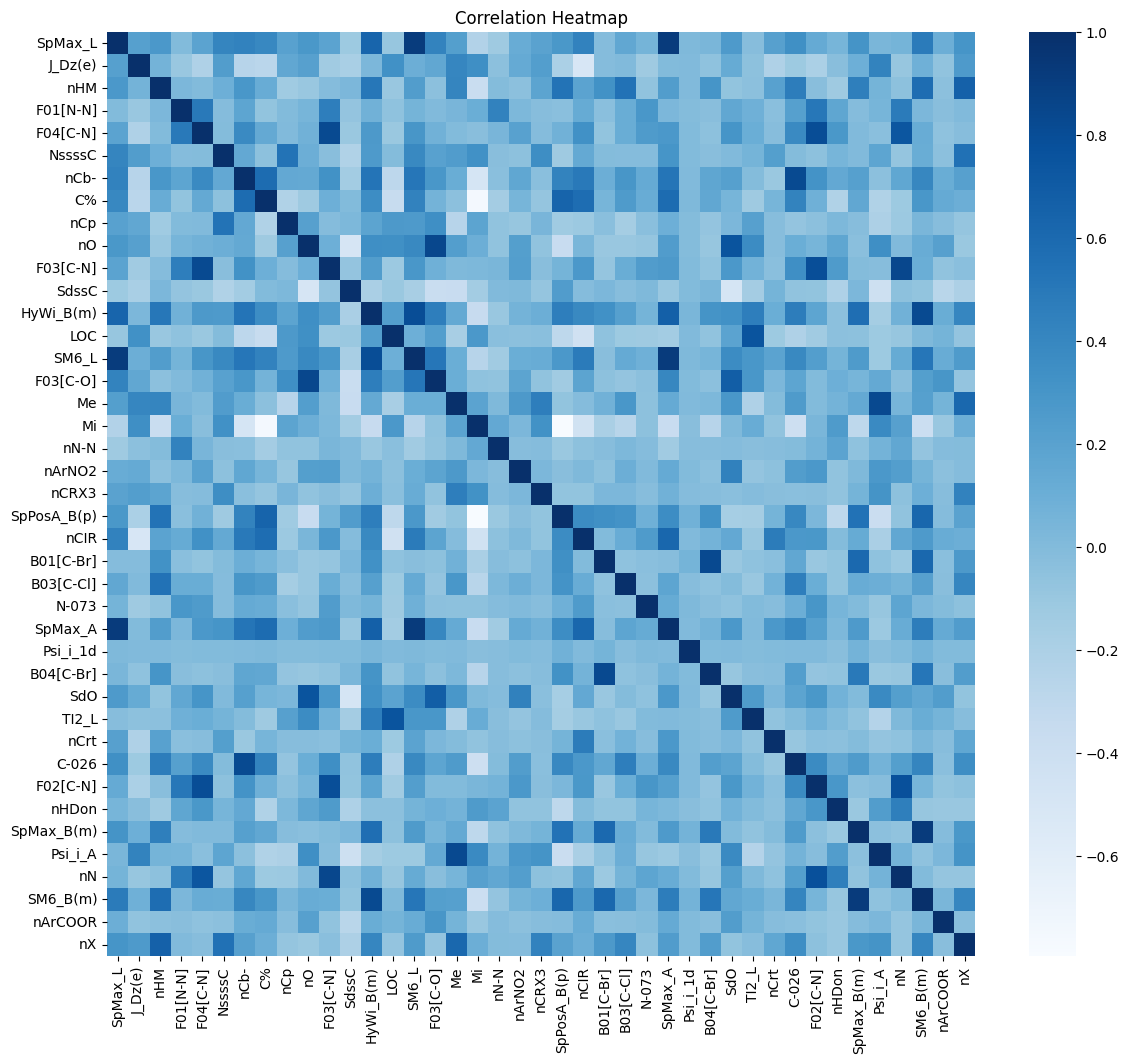

In [11]:
corr_matrix=data.drop('Class', axis=1).corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix,cmap='Blues')
plt.title('Correlation Heatmap')
plt.savefig('Correlation_Heatmap.png',dpi=300,bbox_inches='tight')
plt.show()

### Feature Distribution Analysis

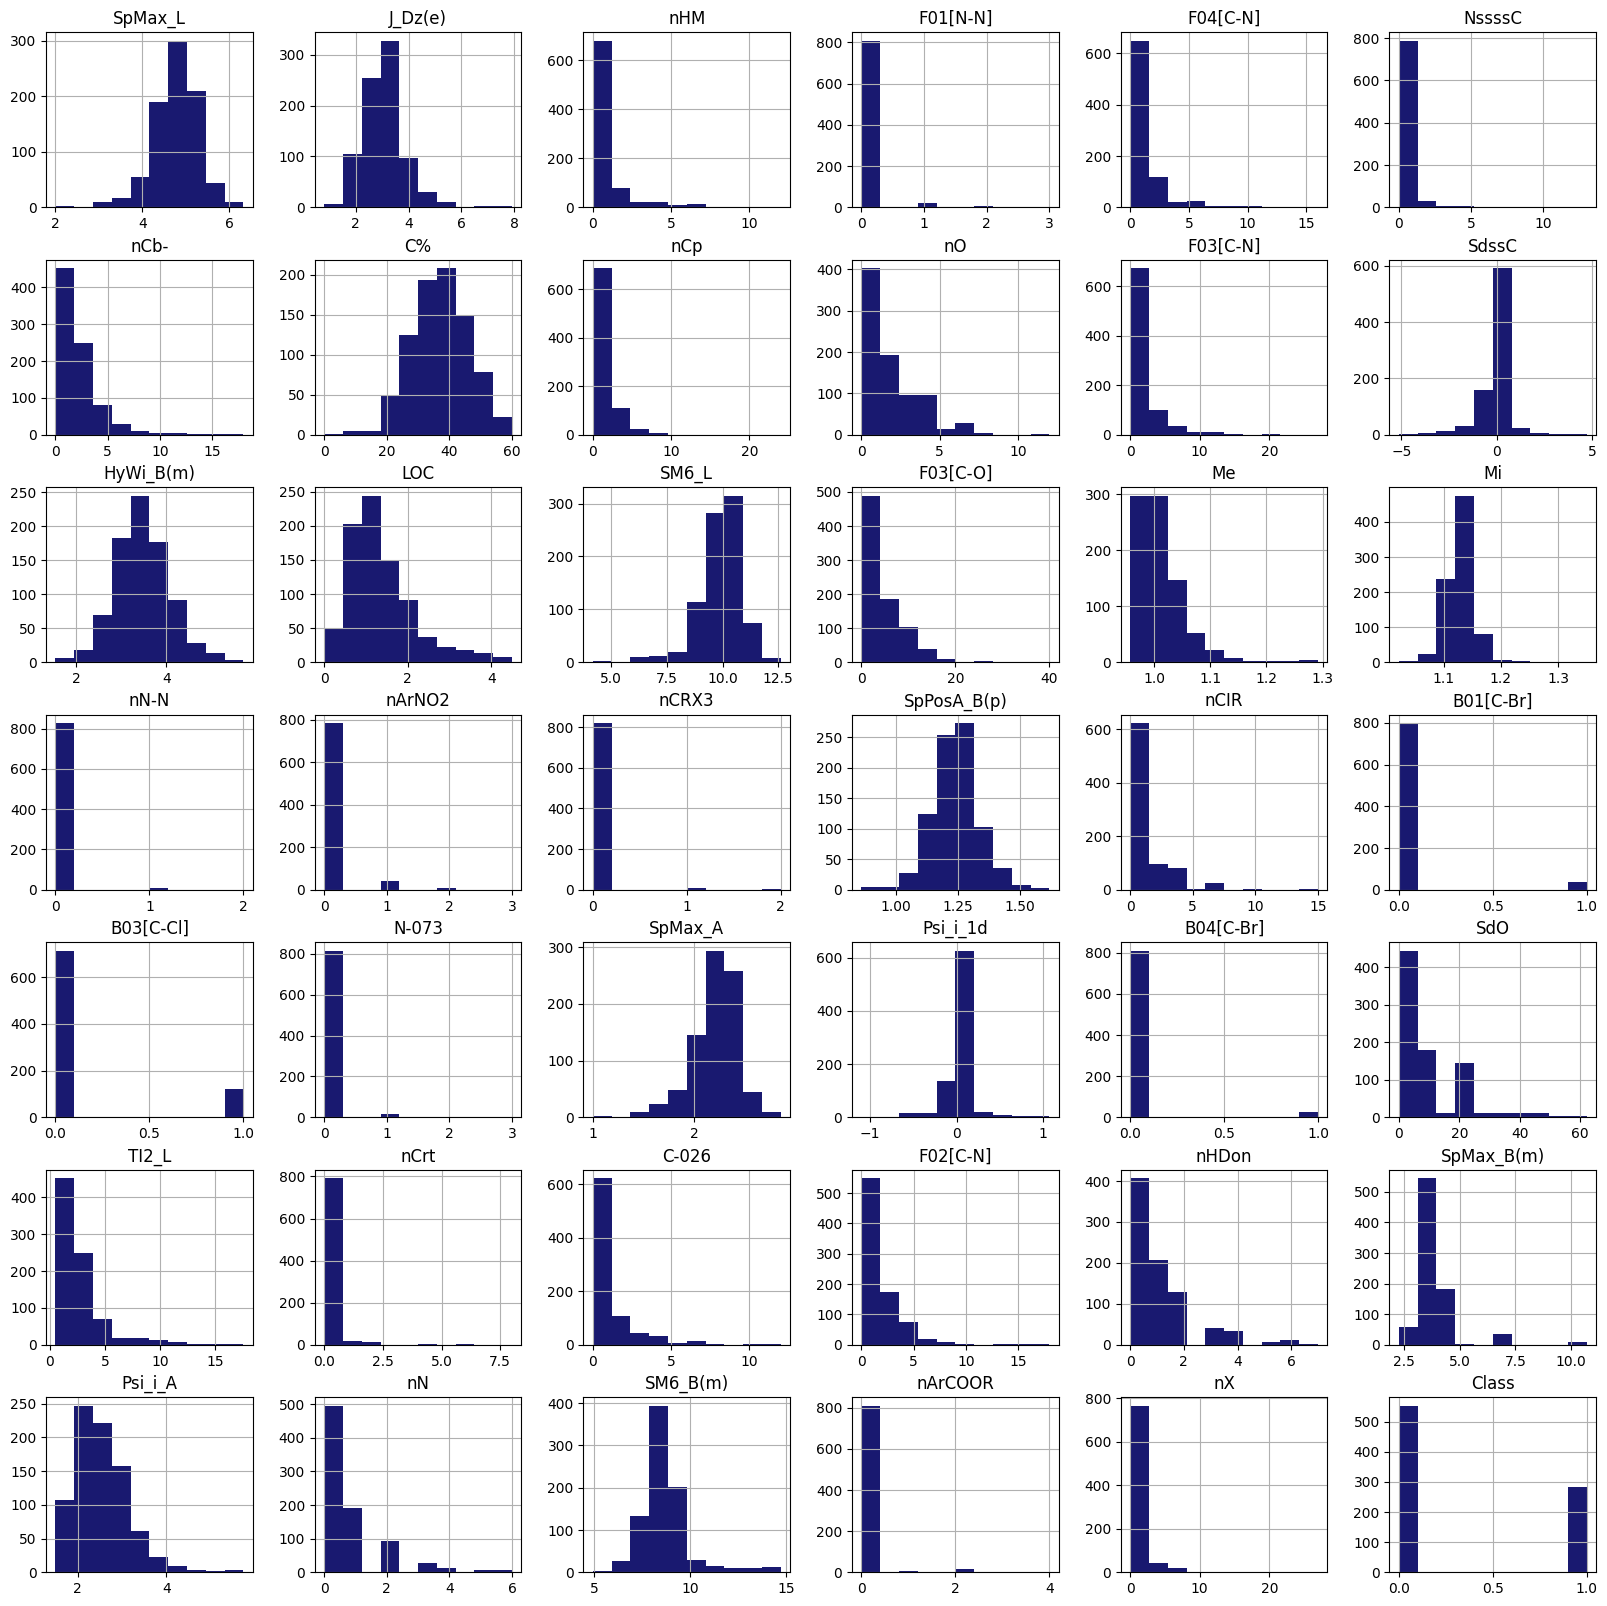

In [12]:
data.hist(figsize=(20,20),color='midnightblue')
plt.savefig('Histogram.png',dpi=300,bbox_inches='tight')
plt.show()

### Outlier Analysis Using Boxplots

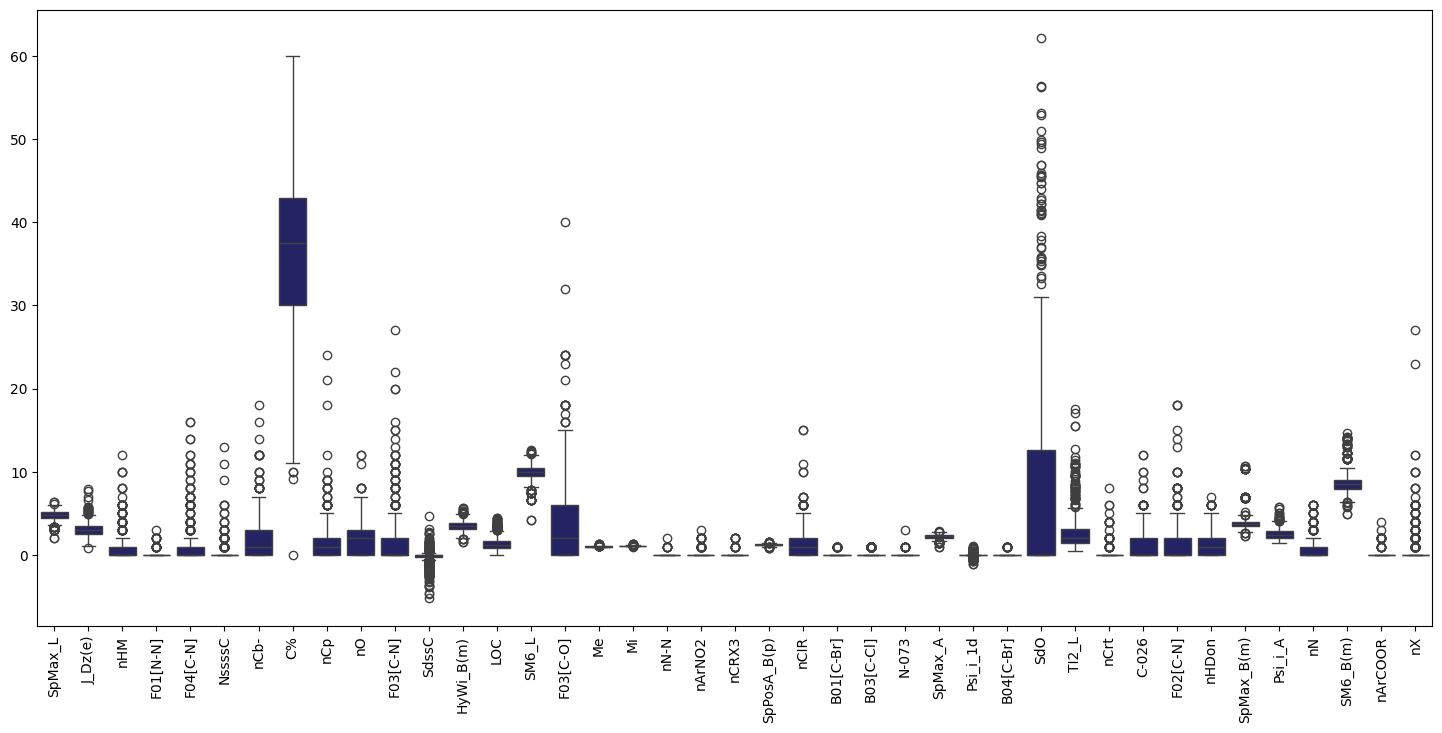

In [13]:
plt.figure(figsize=(18,8))
sns.boxplot(data=data.drop('Class', axis=1),color='midnightblue')
plt.xticks(rotation=90)
plt.savefig('Boxplots.png',dpi=300,bbox_inches='tight')
plt.show()

## Feature Scaling

In [14]:
x=data.drop('Class',axis=1)

In [15]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

### Checking Scaled Data

In [16]:
scaled_data=pd.DataFrame(x_scaled,columns=x.columns)
scaled_data.head()

,SpMax_L,J_Dz(e),nHM,F01[N-N],F04[C-N],NssssC,nCb-,C%,nCp,nO,...,nCrt,C-026,F02[C-N],nHDon,SpMax_B(m),Psi_i_A,nN,SM6_B(m),nArCOOR,nX
0,-1.570613,-0.462162,-0.492022,-0.168837,-0.459033,-0.272746,-0.724018,-0.603765,0.286996,-1.013904,...,-0.188237,-0.583278,-0.569908,-0.760467,-0.943156,-1.557287,-0.636613,-1.078778,-0.163631,-0.342267
1,-1.109034,-1.182499,-0.492022,-0.168837,-0.459033,-0.272746,-0.724018,-0.669388,-0.199092,-0.455822,...,-0.188237,-0.583278,-0.569908,-0.760467,-0.592727,-0.944314,-0.636613,-1.075671,-0.163631,-0.342267
2,-1.546706,0.237933,-0.492022,-0.168837,-0.459033,-0.272746,-0.724018,-1.117817,0.286996,1.218422,...,-0.188237,-0.583278,-0.569908,0.008286,-0.821559,-0.210704,-0.636613,-0.808516,-0.163631,-0.342267
3,-3.260617,-0.438546,-0.492022,-0.168837,-0.459033,-0.272746,-0.724018,-1.850615,-0.685180,0.102259,...,-0.188237,-0.583278,-0.569908,0.008286,-0.850283,4.000220,-0.636613,-1.516013,-0.163631,-0.342267
4,-0.987662,0.416862,-0.492022,-0.168837,-0.459033,-0.272746,-0.724018,-0.822510,0.286996,1.218422,...,-0.188237,-0.583278,-0.569908,-0.760467,-0.558259,-0.230267,-0.636613,-0.496316,-0.163631,-0.342267


In [17]:
scaled_data.describe()

,SpMax_L,J_Dz(e),nHM,F01[N-N],F04[C-N],NssssC,nCb-,C%,nCp,nO,...,nCrt,C-026,F02[C-N],nHDon,SpMax_B(m),Psi_i_A,nN,SM6_B(m),nArCOOR,nX
count,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02,...,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02,8.350000e+02
mean,-1.225367e-15,5.339707e-16,-1.701899e-17,-3.403798e-17,3.403798e-17,5.531171e-17,6.807595e-17,-5.105696e-17,8.509494e-18,-4.254747e-17,...,1.701899e-17,-1.701899e-17,1.701899e-17,-5.105696e-17,-3.744177e-16,-7.658544e-17,1.701899e-17,3.744177e-16,-1.701899e-17,3.403798e-17
std,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00,...,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00,1.000599e+00
min,-5.099577e+00,-2.819969e+00,-4.920217e-01,-1.688374e-01,-4.590328e-01,-2.727460e-01,-7.240184e-01,-4.038073e+00,-6.851800e-01,-1.013904e+00,...,-1.882374e-01,-5.832781e-01,-5.699078e-01,-7.604675e-01,-1.596141e+00,-1.705639e+00,-6.366129e-01,-2.892952e+00,-1.636310e-01,-3.422671e-01
25%,-5.463120e-01,-7.097501e-01,-4.920217e-01,-1.688374e-01,-4.590328e-01,-2.727460e-01,-7.240184e-01,-7.459492e-01,-6.851800e-01,-1.013904e+00,...,-1.882374e-01,-5.832781e-01,-5.699078e-01,-7.604675e-01,-4.337894e-01,-7.274916e-01,-6.366129e-01,-5.118484e-01,-1.636310e-01,-3.422671e-01
50%,9.548496e-02,-1.421572e-02,-4.920217e-01,-1.688374e-01,-4.590328e-01,-2.727460e-01,-2.881457e-01,6.341007e-02,-1.990922e-01,1.022592e-01,...,-1.882374e-01,-5.832781e-01,-5.699078e-01,8.285965e-03,-2.059149e-01,-1.373428e-01,-6.366129e-01,-1.041251e-01,-1.636310e-01,-3.422671e-01
75%,6.361391e-01,4.820234e-01,1.706204e-01,-1.688374e-01,2.128348e-02,-2.727460e-01,5.835995e-01,6.540236e-01,2.869955e-01,6.603408e-01,...,-1.882374e-01,6.768441e-01,3.271196e-01,7.770394e-01,5.594924e-02,5.359485e-01,2.705062e-01,3.067046e-01,-1.636310e-01,-3.422671e-01
max,2.863119e+00,6.069602e+00,7.459683e+00,1.157943e+01,7.226028e+00,1.330825e+01,7.121689e+00,2.524300e+00,1.098093e+01,5.683074e+00,...,1.251304e+01,6.977455e+00,7.503339e+00,4.620807e+00,6.473297e+00,5.209862e+00,4.806101e+00,4.704679e+00,1.198142e+01,1.348643e+01


## Principal Component Analysis (PCA)

In [18]:
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

In [19]:
x_pca.shape

(835, 2)

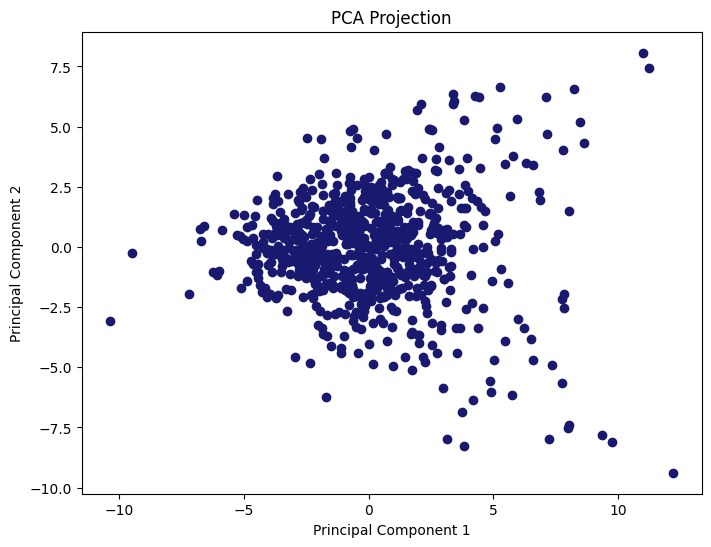

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],color='midnightblue')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection')
plt.savefig('PCA Projection.png',dpi=300,bbox_inches='tight')
plt.show()

In [21]:
pca.explained_variance_ratio_

array([0.19064655, 0.12026284])

### Selecting the Optimal Number of PCA Components

In [22]:
pca=PCA()
pca.fit(x_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [23]:
cumulative_variance=np.cumsum(pca.explained_variance_ratio_)

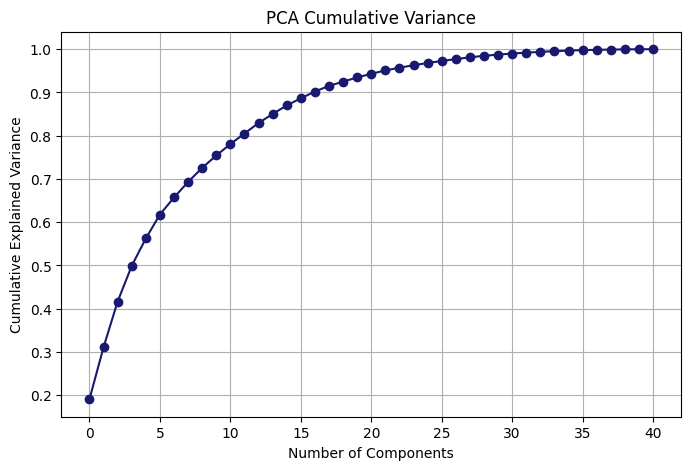

In [24]:
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance,marker='o',color='midnightblue')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Variance')
plt.grid()
plt.savefig('PCA Cumulative Variance.png',dpi=300,bbox_inches='tight')
plt.show()

In [25]:
np.argmax(cumulative_variance >= 0.90) + 1

np.int64(17)

In [26]:
pca=PCA(n_components=17)
x_pca_17= pca.fit_transform(x_scaled)

## Feature and Target Separation

In [27]:
x=data.drop('Class',axis=1)
x2=x_pca
y=data['Class']

## Train-Test Split

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

## Logistic Regression

In [29]:
lr=LogisticRegression(max_iter=5000)
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

In [30]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.8622754491017964
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       111
           1       0.82      0.75      0.79        56

    accuracy                           0.86       167
   macro avg       0.85      0.83      0.84       167
weighted avg       0.86      0.86      0.86       167



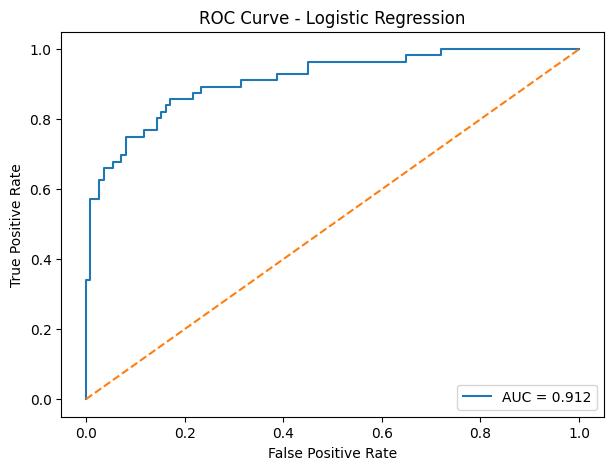

AUC: 0.9115186615186615


In [31]:
y_prob=lr.predict_proba(x_test)[:, 1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
roc_auc=auc(fpr, tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.savefig('ROC Curve - Logistic Regression.png',dpi=300,bbox_inches='tight')
plt.show()
print("AUC:",roc_auc)

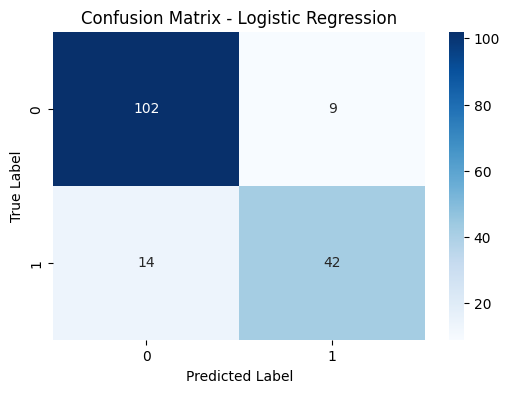

In [32]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('Confusion Matrix - Logistic Regression.png',dpi=300,bbox_inches='tight')
plt.show()

The Logistic Regression model achieved an accuracy of 86.23% on the test dataset. The confusion matrix showed that 102 samples from Class 0 and 42 samples from Class 1 were correctly classified. The model demonstrated good predictive performance, with a precision of 0.82, recall of 0.75, and F1-score of 0.79 for Class 1.
Overall, Logistic Regression provided a strong baseline classifier and demonstrated the ability to effectively distinguish between the two classes.

##  Random Forest Classifier

In [33]:
rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8622754491017964
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       111
           1       0.84      0.73      0.78        56

    accuracy                           0.86       167
   macro avg       0.85      0.83      0.84       167
weighted avg       0.86      0.86      0.86       167



In [35]:
importance=pd.DataFrame({'Feature': x.columns,'Importance': rf.feature_importances_})
importance=importance.sort_values(by='Importance',ascending=False)
importance.head(10)

,Feature,Importance
35,SpMax_B(m),0.071645
0,SpMax_L,0.069037
21,SpPosA_B(p),0.067175
38,SM6_B(m),0.064914
26,SpMax_A,0.061768
14,SM6_L,0.037409
12,HyWi_B(m),0.037001
36,Psi_i_A,0.036101
33,F02[C-N],0.035345
1,J_Dz(e),0.034872


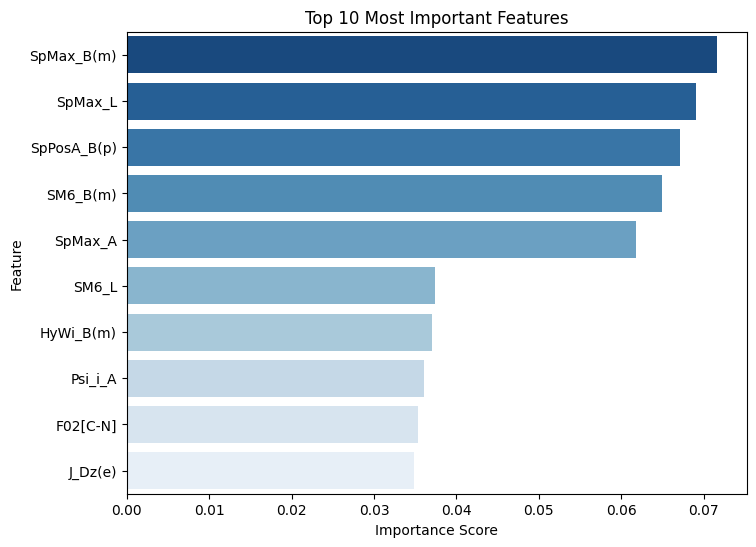

In [36]:
top10=importance.head(10)
plt.figure(figsize=(8,6))
sns.barplot(data=top10,x='Importance',y='Feature',palette='Blues_r')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.savefig('Top 10 Most Important Features.png',dpi=300,bbox_inches='tight')
plt.show()

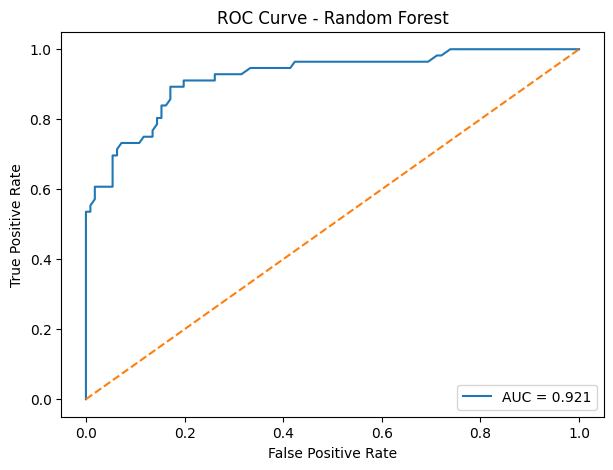

AUC: 0.9206885456885457


In [37]:
y_prob_rf=rf.predict_proba(x_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob_rf)
roc_auc_rf=auc(fpr, tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f'AUC = {roc_auc_rf:.3f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.show()
print("AUC:", roc_auc_rf)

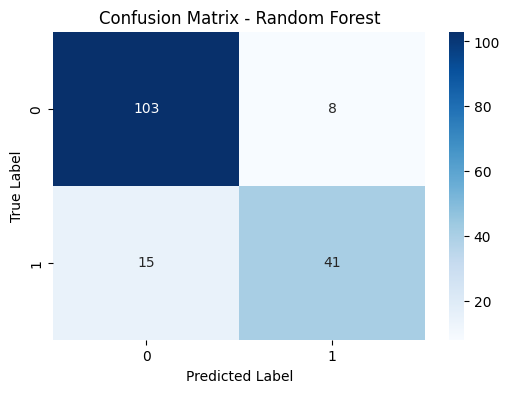

In [38]:
cm=confusion_matrix(y_test,y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('Confusion Matrix - Random Forest.png',dpi=300,bbox_inches='tight')
plt.show()

The Random Forest classifier achieved an accuracy of 86.23% on the testing dataset. The confusion matrix indicated that 103 samples from Class 0 and 41 samples from Class 1 were correctly classified.
When compared with Logistic Regression, Random Forest did not provide a significant improvement in overall performance. Both models achieved the same accuracy, while Logistic Regression showed a slightly higher recall and F1-score for Class 1. Therefore, the additional complexity of the ensemble model did not lead to better predictive performance for this dataset.

## Support Vector Machine (SVM)

In [39]:
svm=SVC(kernel='rbf',C=1,gamma='scale',probability=True,random_state=42)
svm.fit(x_train,y_train)
y_pred_svm=svm.predict(x_test)

In [40]:
print("Accuracy:", accuracy_score(y_test,y_pred_svm))
print(classification_report(y_test,y_pred_svm))

Accuracy: 0.7844311377245509
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       111
           1       0.72      0.59      0.65        56

    accuracy                           0.78       167
   macro avg       0.76      0.74      0.75       167
weighted avg       0.78      0.78      0.78       167



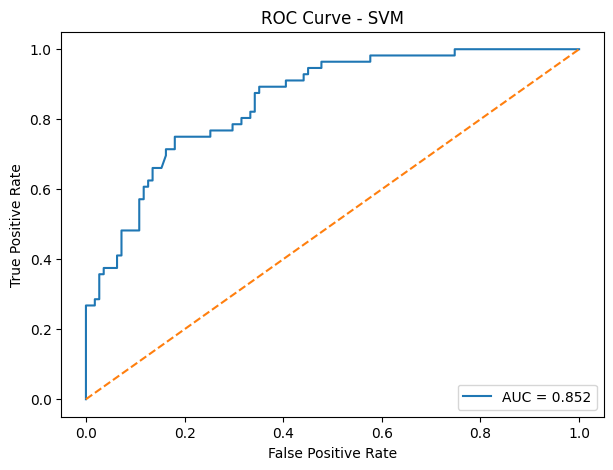

AUC: 0.8524774774774775


In [41]:
y_prob_svm=svm.predict_proba(x_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob_svm)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.show()
print("AUC:", roc_auc)

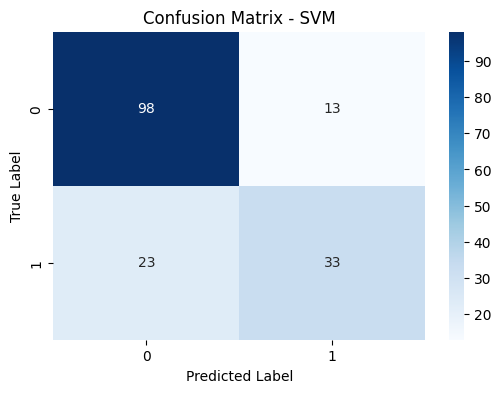

In [42]:
cm=confusion_matrix(y_test,y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('Confusion Matrix - SVM.png',dpi=300,bbox_inches='tight')
plt.show()

The confusion matrix revealed that the SVM classifier produced a higher number of misclassifications compared with Logistic Regression and Random Forest. This observation is consistent with the lower accuracy, recall, and F1-score obtained by the SVM model, indicating a weaker overall classification performance on this dataset.

## K-Nearest Neighbors (KNN)

In [43]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred_knn=knn.predict(x_test)

In [44]:
print("Accuracy:",accuracy_score(y_test,y_pred_knn))
print(classification_report(y_test,y_pred_knn))

Accuracy: 0.7604790419161677
              precision    recall  f1-score   support

           0       0.87      0.76      0.81       111
           1       0.61      0.77      0.68        56

    accuracy                           0.76       167
   macro avg       0.74      0.76      0.75       167
weighted avg       0.78      0.76      0.77       167



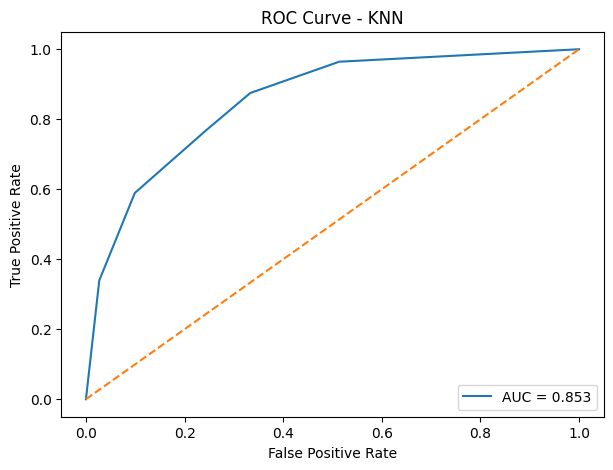

AUC: 0.8533622908622909


In [45]:
y_prob_knn=knn.predict_proba(x_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob_knn)
roc_auc_knn=auc(fpr,tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f'AUC = {roc_auc_knn:.3f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend(loc='lower right')
plt.show()
print("AUC:", roc_auc_knn)

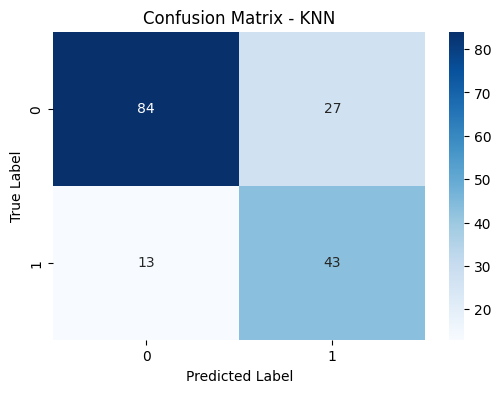

In [46]:
cm=confusion_matrix(y_test,y_pred_knn)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Gradient Boosting Classifier

In [47]:
gb=GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,max_depth=3,random_state=42)
gb.fit(x_train,y_train)
y_pred_gb=gb.predict(x_test)

In [48]:
print("Accuracy:",accuracy_score(y_test,y_pred_gb))
print(classification_report(y_test,y_pred_gb))

Accuracy: 0.8682634730538922
              precision    recall  f1-score   support

           0       0.86      0.95      0.91       111
           1       0.89      0.70      0.78        56

    accuracy                           0.87       167
   macro avg       0.87      0.83      0.84       167
weighted avg       0.87      0.87      0.86       167



In [49]:
importance_gb=pd.DataFrame({'Feature': x.columns,'Importance': gb.feature_importances_})
importance_gb=importance_gb.sort_values(by='Importance',ascending=False)
importance_gb.head(15)

,Feature,Importance
35,SpMax_B(m),0.186458
0,SpMax_L,0.095090
21,SpPosA_B(p),0.087140
38,SM6_B(m),0.069407
29,SdO,0.060727
37,nN,0.058551
39,nArCOOR,0.051771
36,Psi_i_A,0.047894
33,F02[C-N],0.040402
12,HyWi_B(m),0.038312


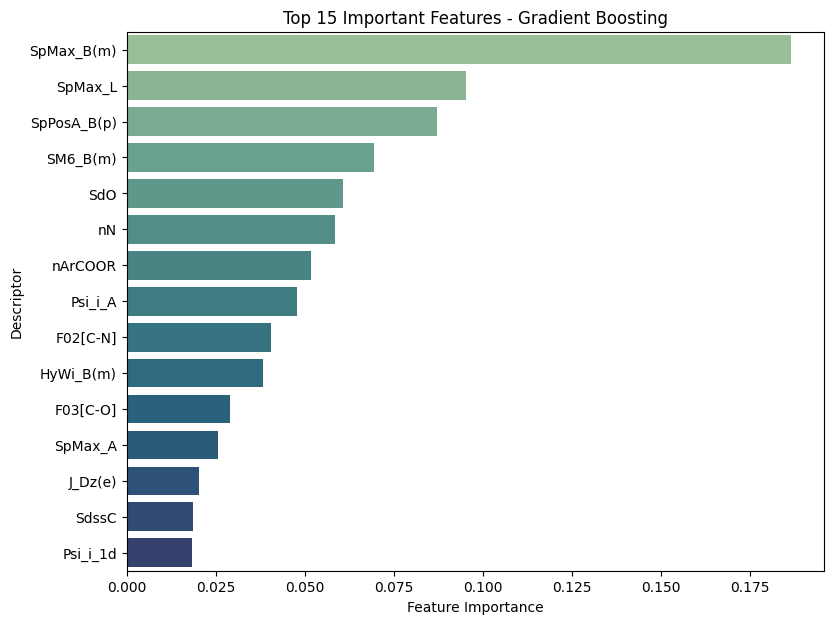

In [50]:
top15=importance_gb.head(15)
plt.figure(figsize=(9,7))
sns.barplot(data=top15,x='Importance',y='Feature',palette='crest')
plt.title('Top 15 Important Features - Gradient Boosting')
plt.xlabel('Feature Importance')
plt.ylabel('Descriptor')
plt.show()

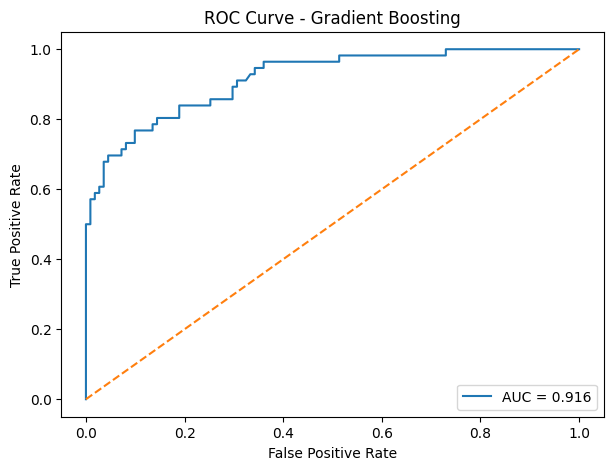

AUC: 0.9159427284427284


In [51]:
y_prob_gb=gb.predict_proba(x_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob_gb)
roc_auc_gb=auc(fpr,tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f'AUC = {roc_auc_gb:.3f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend(loc='lower right')
plt.show()
print("AUC:", roc_auc_gb)

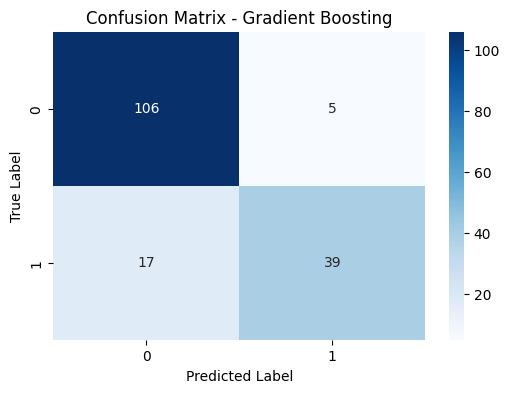

In [52]:
cm=confusion_matrix(y_test,y_pred_gb)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## AdaBoost Classifier

In [53]:
ada=AdaBoostClassifier(n_estimators=200,learning_rate=0.5,random_state=42)
ada.fit(x_train,y_train)
y_pred_ada=ada.predict(x_test)

In [54]:
print("Accuracy:",accuracy_score(y_test,y_pred_ada))
print(classification_report(y_test,y_pred_ada))

Accuracy: 0.8383233532934131
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       111
           1       0.75      0.77      0.76        56

    accuracy                           0.84       167
   macro avg       0.82      0.82      0.82       167
weighted avg       0.84      0.84      0.84       167



In [55]:
importance_ada=pd.DataFrame({'Feature': x.columns,'Importance': ada.feature_importances_})
importance_ada=importance_ada.sort_values(by='Importance',ascending=False)
importance_ada.head(15)

,Feature,Importance
35,SpMax_B(m),0.192085
5,NssssC,0.100511
6,nCb-,0.084724
17,Mi,0.082437
40,nX,0.075946
0,SpMax_L,0.066604
37,nN,0.065892
33,F02[C-N],0.055244
19,nArNO2,0.043198
39,nArCOOR,0.036508


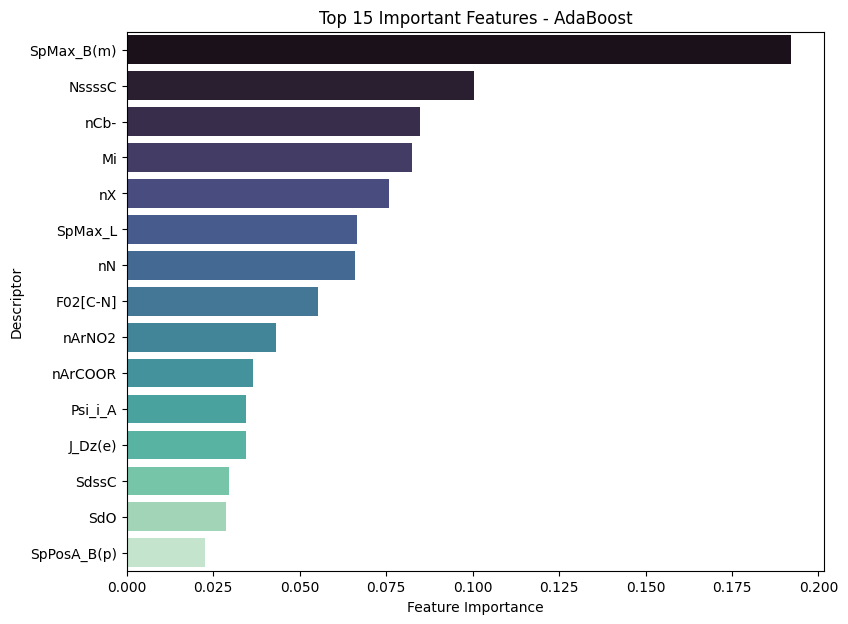

In [56]:
top15=importance_ada.head(15)
plt.figure(figsize=(9,7))
sns.barplot(data=top15,x='Importance',y='Feature',palette='mako')
plt.title('Top 15 Important Features - AdaBoost')
plt.xlabel('Feature Importance')
plt.ylabel('Descriptor')
plt.show()

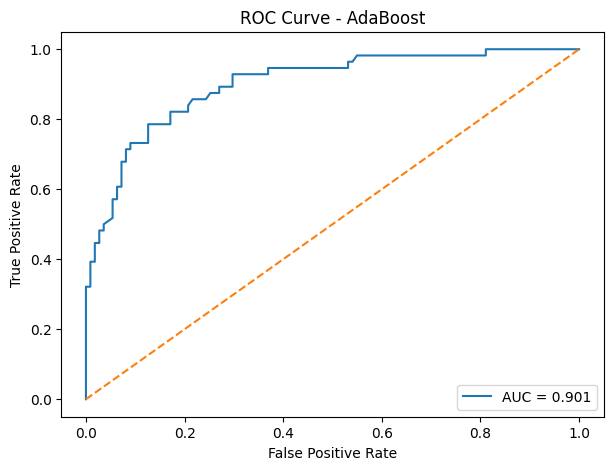

AUC: 0.9006595881595881


In [57]:
y_prob_ada=ada.predict_proba(x_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob_ada)
roc_auc_ada=auc(fpr, tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f'AUC = {roc_auc_ada:.3f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - AdaBoost')
plt.legend(loc='lower right')

plt.show()

print("AUC:", roc_auc_ada)

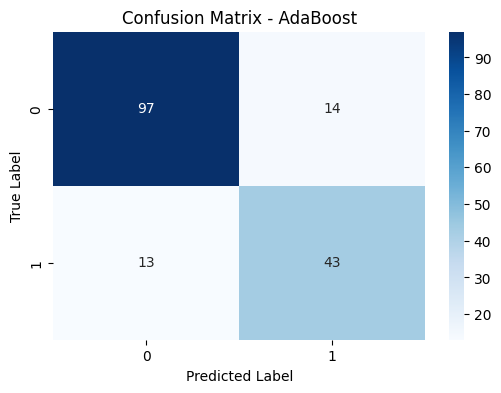

In [58]:
cm=confusion_matrix(y_test,y_pred_ada)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix - AdaBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Decision Tree Classifier

In [59]:
dt=DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(x_train,y_train)
y_pred_dt=dt.predict(x_test)

In [60]:
print("Accuracy:",accuracy_score(y_test,y_pred_dt))
print(classification_report(y_test,y_pred_dt))

Accuracy: 0.8502994011976048
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       111
           1       0.78      0.77      0.77        56

    accuracy                           0.85       167
   macro avg       0.83      0.83      0.83       167
weighted avg       0.85      0.85      0.85       167



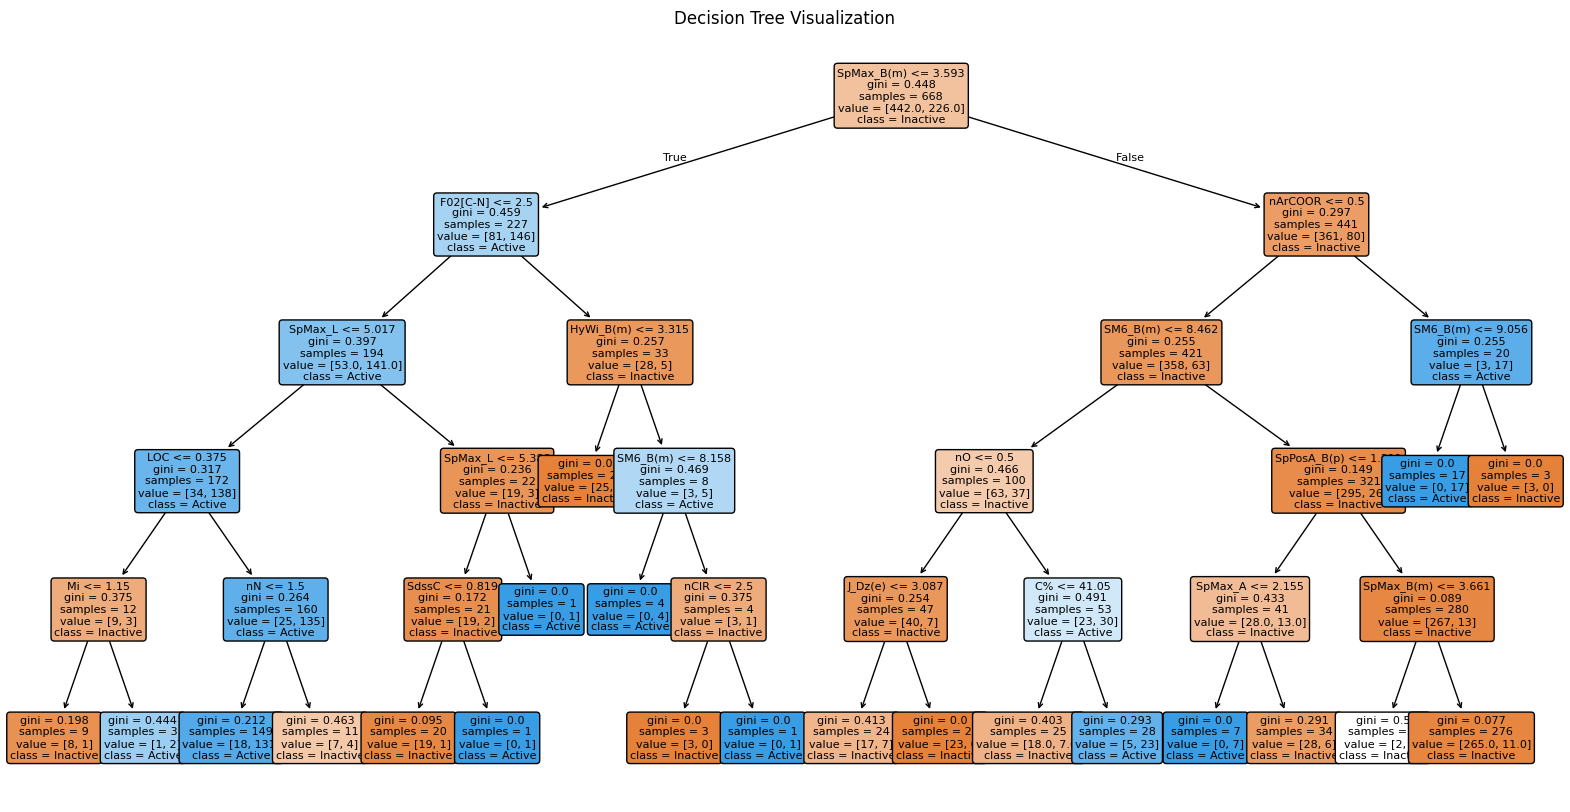

In [61]:
plt.figure(figsize=(20,10))
plot_tree(dt,feature_names=x.columns,class_names=['Inactive','Active'],filled=True,rounded=True,fontsize=8)
plt.title('Decision Tree Visualization')
plt.show()

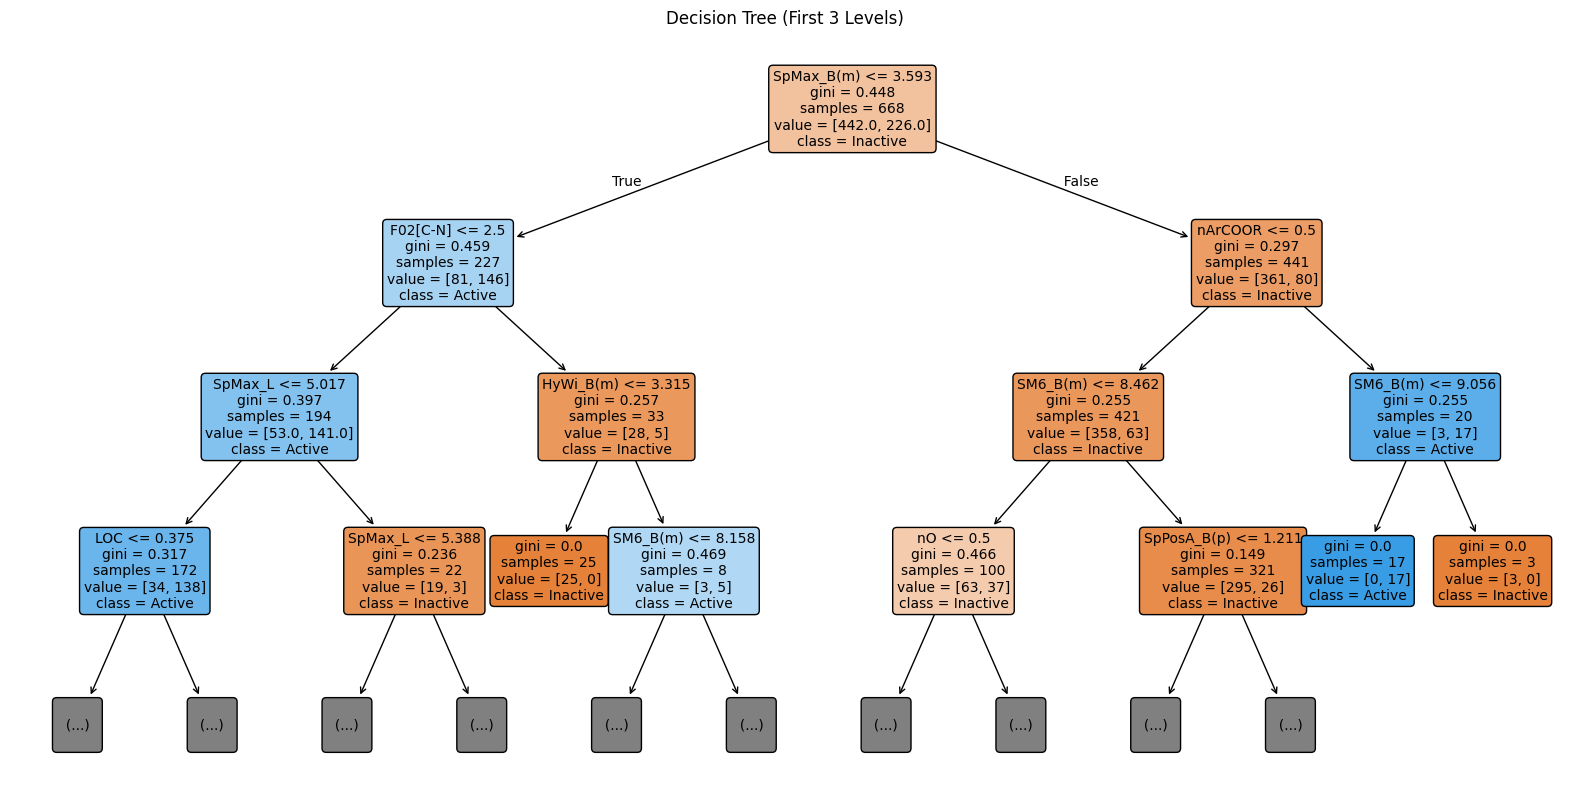

In [62]:
plt.figure(figsize=(20,10))
plot_tree(dt,feature_names=x.columns,class_names=['Inactive','Active'],filled=True,rounded=True,fontsize=10,max_depth=3)
plt.title('Decision Tree (First 3 Levels)')
plt.show()

In [63]:
tree_rules=export_text(dt,feature_names=list(x.columns))
print(tree_rules)

|--- SpMax_B(m) <= 3.59
|   |--- F02[C-N] <= 2.50
|   |   |--- SpMax_L <= 5.02
|   |   |   |--- LOC <= 0.38
|   |   |   |   |--- Mi <= 1.15
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Mi >  1.15
|   |   |   |   |   |--- class: 1
|   |   |   |--- LOC >  0.38
|   |   |   |   |--- nN <= 1.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- nN >  1.50
|   |   |   |   |   |--- class: 0
|   |   |--- SpMax_L >  5.02
|   |   |   |--- SpMax_L <= 5.39
|   |   |   |   |--- SdssC <= 0.82
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- SdssC >  0.82
|   |   |   |   |   |--- class: 1
|   |   |   |--- SpMax_L >  5.39
|   |   |   |   |--- class: 1
|   |--- F02[C-N] >  2.50
|   |   |--- HyWi_B(m) <= 3.31
|   |   |   |--- class: 0
|   |   |--- HyWi_B(m) >  3.31
|   |   |   |--- SM6_B(m) <= 8.16
|   |   |   |   |--- class: 1
|   |   |   |--- SM6_B(m) >  8.16
|   |   |   |   |--- nCIR <= 2.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- nCIR >  2.50
|   |   |   |   |   |-

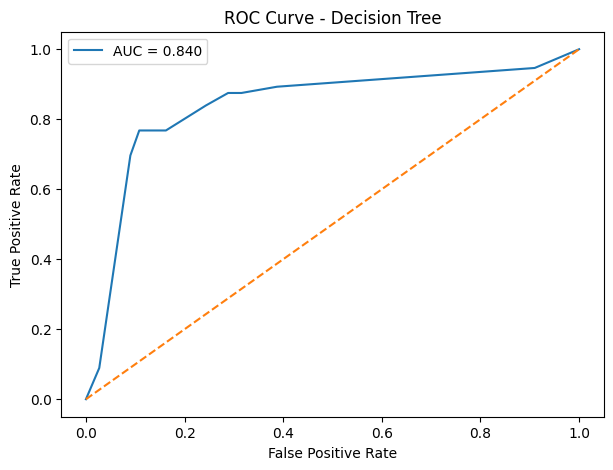

AUC: 0.8400096525096525


In [64]:
y_prob_dt=dt.predict_proba(x_test)[:,1]
fpr,tpr,_=roc_curve(y_test,y_prob_dt)
roc_auc_dt=auc(fpr,tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f'AUC = {roc_auc_dt:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.show()
print("AUC:", roc_auc_dt)

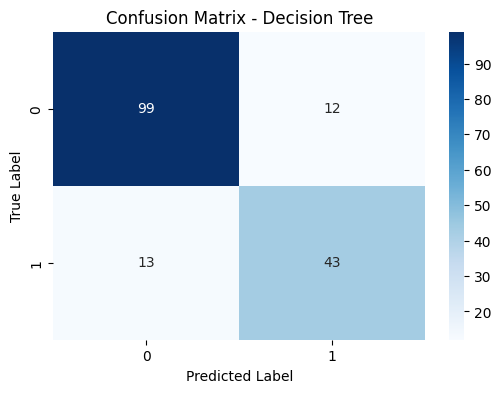

In [65]:
cm=confusion_matrix(y_test,y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The Decision Tree analysis revealed that the descriptor SpMax_B(m) was selected as the root node of the tree, indicating its primary role in the classification process. Several additional descriptors, including F02[C-N], SpMax_L, nN, SM6_B(m), SpPosA_B(p), and nArCOOR, were also used throughout the decision structure.
Interestingly, these descriptors were consistently identified as important variables by Random Forest, Gradient Boosting, and AdaBoost feature importance analyses. The agreement between multiple machine learning algorithms suggests that these molecular descriptors are highly relevant for distinguishing active and inactive compounds.
Although the Decision Tree achieved reasonable predictive performance, ensemble methods demonstrated superior classification accuracy and discriminative capability, highlighting the advantages of combining multiple learners.

## Gaussian Naive Bayes

In [66]:
gnb=GaussianNB()
gnb.fit(x_train,y_train)
y_pred_gnb=gnb.predict(x_test)

In [67]:
print("Accuracy:",accuracy_score(y_test,y_pred_gnb))
print(classification_report(y_test,y_pred_gnb))

Accuracy: 0.6946107784431138
              precision    recall  f1-score   support

           0       0.94      0.58      0.72       111
           1       0.53      0.93      0.67        56

    accuracy                           0.69       167
   macro avg       0.73      0.75      0.69       167
weighted avg       0.80      0.69      0.70       167



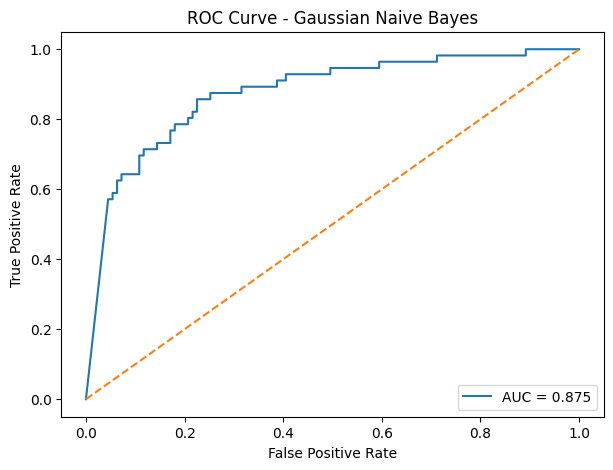

AUC: 0.8748391248391248


In [68]:
y_prob_gnb=gnb.predict_proba(x_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob_gnb)
roc_auc_gnb=auc(fpr,tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f'AUC = {roc_auc_gnb:.3f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gaussian Naive Bayes')
plt.legend(loc='lower right')
plt.show()
print("AUC:", roc_auc_gnb)

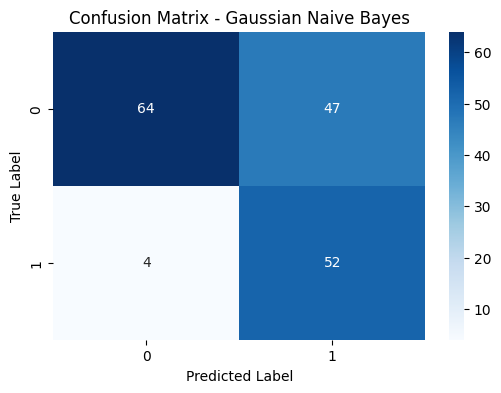

In [69]:
cm=confusion_matrix(y_test,y_pred_gnb)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Gaussian Naive Bayes achieved the lowest classification accuracy among the evaluated models (69.46%), although its AUC value remained relatively high (0.875).
The model demonstrated very high recall for the active class but showed limited ability to correctly identify inactive compounds. This behavior suggests that the classifier was biased toward predicting the positive class.
A possible explanation is the strong independence assumption of Naive Bayes. Molecular descriptors in QSAR datasets are often correlated, which violates this assumption and can reduce classification performance.
Consequently, Gaussian Naive Bayes was less effective than tree-based ensemble methods and Logistic Regression for this dataset.

## Multi-Layer Perceptron (MLP)

In [70]:
mlp=MLPClassifier(hidden_layer_sizes=(100,50),activation='relu',solver='adam',max_iter=5000,random_state=42)
mlp.fit(x_train,y_train)
y_pred_mlp=mlp.predict(x_test)

In [71]:
print("Accuracy:",accuracy_score(y_test,y_pred_mlp))
print(classification_report(y_test,y_pred_mlp))

Accuracy: 0.8143712574850299
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       111
           1       0.78      0.62      0.69        56

    accuracy                           0.81       167
   macro avg       0.80      0.77      0.78       167
weighted avg       0.81      0.81      0.81       167



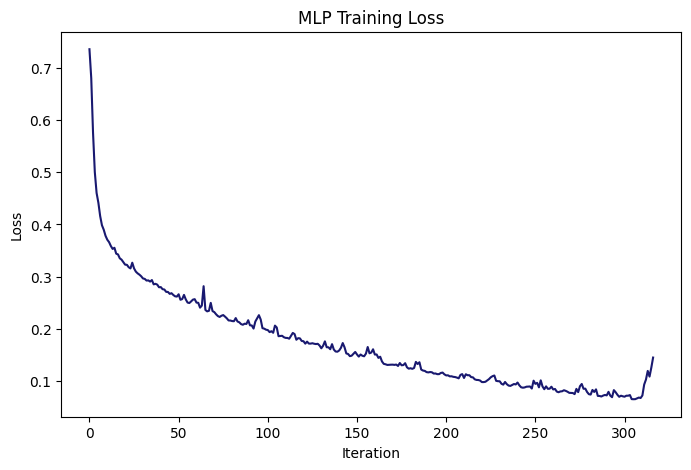

In [72]:
plt.figure(figsize=(8,5))
plt.plot(mlp.loss_curve_,color='midnightblue')
plt.title('MLP Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.savefig("MLP Training Loss.png",dpi=300,bbox_inches="tight")
plt.show()

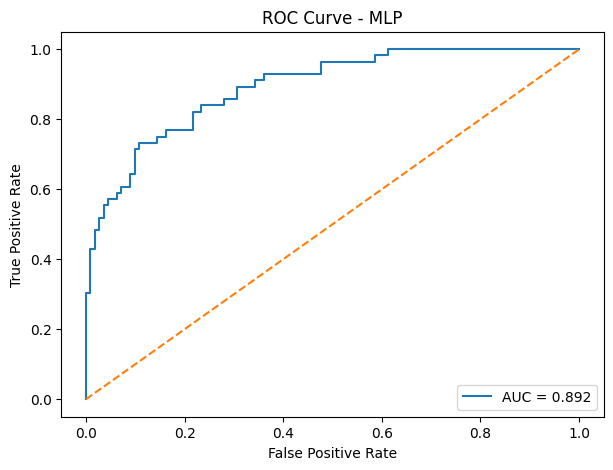

AUC: 0.892052767052767


In [73]:
y_prob_mlp=mlp.predict_proba(x_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob_mlp)
roc_auc_mlp=auc(fpr,tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f'AUC = {roc_auc_mlp:.3f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - MLP')
plt.legend(loc='lower right')
plt.show()
print("AUC:", roc_auc_mlp)

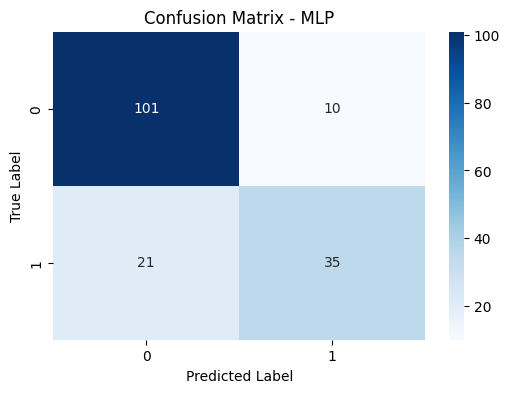

In [74]:
cm=confusion_matrix(y_test,y_pred_mlp)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix - MLP')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The Multi-Layer Perceptron (MLP) classifier achieved an accuracy of 81.44% and an AUC value of 0.892. Although the neural network successfully learned nonlinear patterns in the dataset, its performance remained lower than that of Random Forest, Gradient Boosting, and Logistic Regression.
The training loss curve showed a consistent decrease throughout the learning process, indicating successful optimization of network parameters. However, a slight increase in loss near the final iterations may suggest the beginning of overfitting.
Overall, the neural network provided competitive performance but did not outperform the best ensemble-based approaches for this QSAR classification task.

## Model Comparison

In [75]:
results=pd.DataFrame({'Model':['Logistic Regression','SVM','KNN','Decision Tree','Random Forest','Gradient Boosting','AdaBoost','Gaussian NB','MLP'],
                      'Accuracy':[0.862,0.784,0.760,0.850,0.862,0.868,0.838,0.695,0.814],
                      'AUC':[0.912,0.852,0.853,0.840,0.921,0.916,0.901,0.875,0.892]})
results.sort_values('AUC',ascending=False)

,Model,Accuracy,AUC
4,Random Forest,0.862,0.921
5,Gradient Boosting,0.868,0.916
0,Logistic Regression,0.862,0.912
6,AdaBoost,0.838,0.901
8,MLP,0.814,0.892
7,Gaussian NB,0.695,0.875
2,KNN,0.760,0.853
1,SVM,0.784,0.852
3,Decision Tree,0.850,0.840


In [76]:
results_sorted=results.sort_values(by='AUC',ascending=False).reset_index(drop=True)
results_sorted.index += 1
results_sorted

,Model,Accuracy,AUC
1,Random Forest,0.862,0.921
2,Gradient Boosting,0.868,0.916
3,Logistic Regression,0.862,0.912
4,AdaBoost,0.838,0.901
5,MLP,0.814,0.892
6,Gaussian NB,0.695,0.875
7,KNN,0.760,0.853
8,SVM,0.784,0.852
9,Decision Tree,0.850,0.840


In [77]:
results_sorted=results.sort_values(by='Accuracy',ascending=False).reset_index(drop=True)
results_sorted.index += 1
results_sorted

,Model,Accuracy,AUC
1,Gradient Boosting,0.868,0.916
2,Logistic Regression,0.862,0.912
3,Random Forest,0.862,0.921
4,Decision Tree,0.850,0.840
5,AdaBoost,0.838,0.901
6,MLP,0.814,0.892
7,SVM,0.784,0.852
8,KNN,0.760,0.853
9,Gaussian NB,0.695,0.875


## Accuracy Comparison

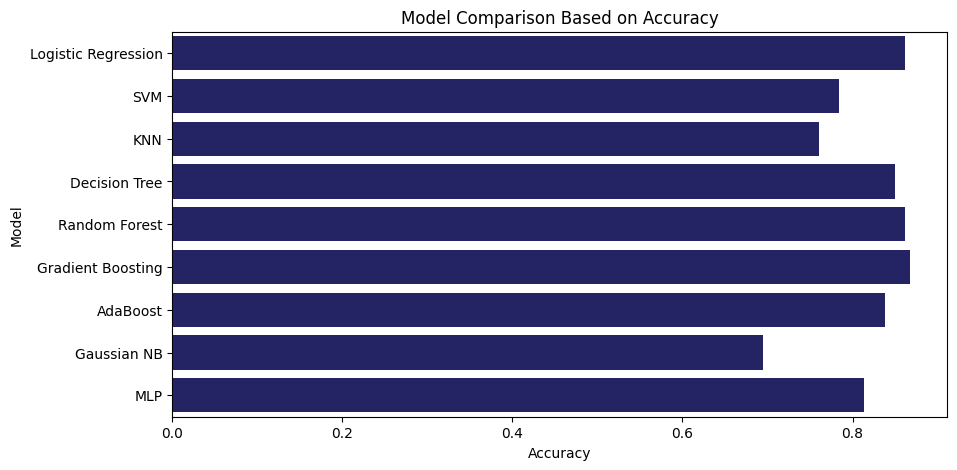

In [78]:
plt.figure(figsize=(10,5))
sns.barplot(data=results,x='Accuracy',y='Model',color='midnightblue')
plt.title('Model Comparison Based on Accuracy')
plt.show()

## ROC-AUC Comparison

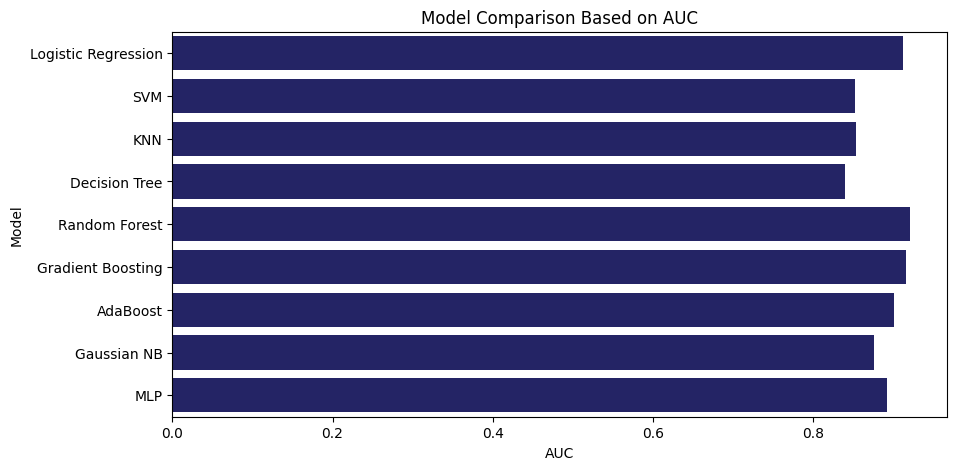

In [79]:
plt.figure(figsize=(10,5))
sns.barplot(data=results,x='AUC',y='Model',color='midnightblue')
plt.title('Model Comparison Based on AUC')
plt.show()

## Feature Importance Analysis

In [80]:
feature_importance_rf=pd.DataFrame({'Feature': x.columns,'Importance': rf.feature_importances_})
feature_importance_rf = feature_importance_rf.sort_values(by='Importance',ascending=False)

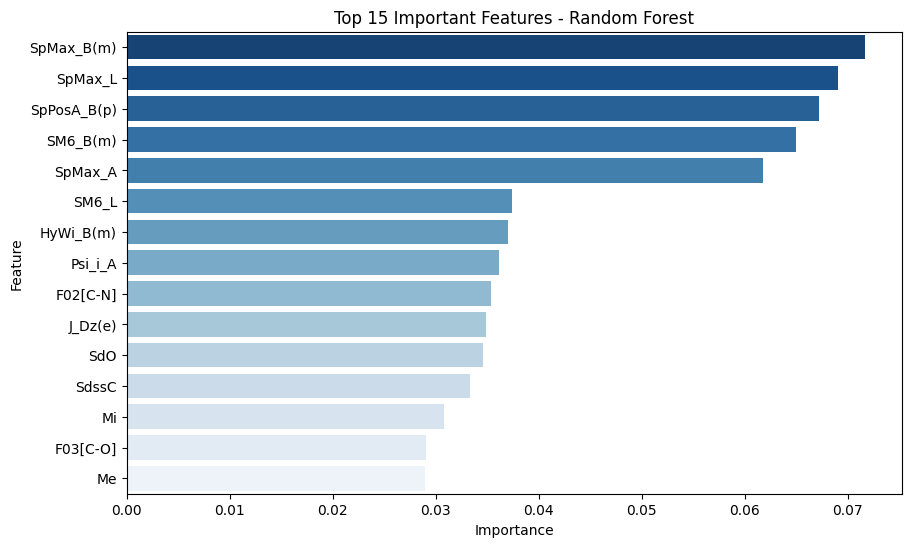

In [81]:
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance_rf.head(15),x='Importance',y='Feature',palette='Blues_r')
plt.title('Top 15 Important Features - Random Forest')
plt.show()

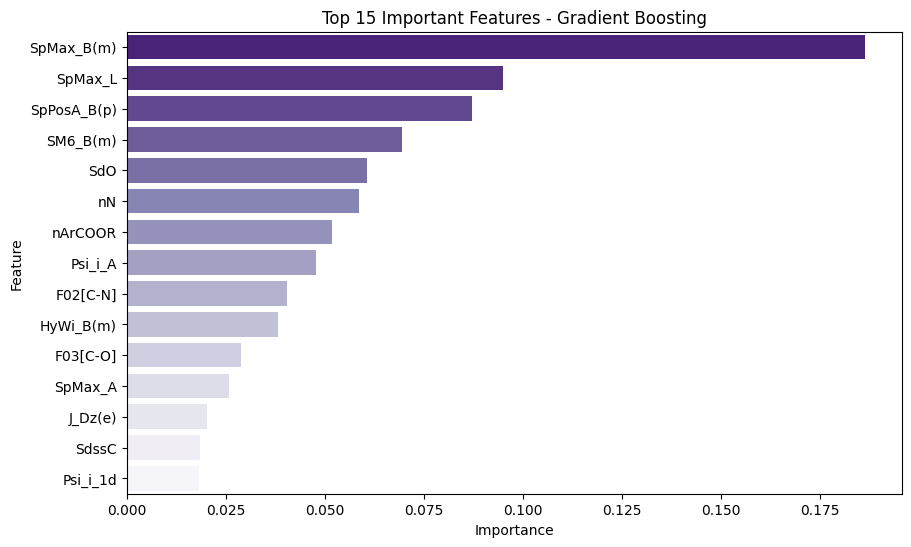

In [82]:
feature_importance_gb=pd.DataFrame({'Feature': x.columns,'Importance': gb.feature_importances_})
feature_importance_gb = feature_importance_gb.sort_values(by='Importance',ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance_gb.head(15),x='Importance',y='Feature',palette='Purples_r')
plt.title('Top 15 Important Features - Gradient Boosting')
plt.show()

## Hyperparameter Tuning for Random Forest

In [83]:
param_grid={'n_estimators': [100, 200, 300],'max_depth': [5, 10, 15, None],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),param_grid=param_grid,cv=5,scoring='roc_auc',n_jobs=-1)
rf_grid.fit(x_train, y_train)
print("Best Parameters:")
print(rf_grid.best_params_)
print("\nBest CV AUC:")
print(rf_grid.best_score_)

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best CV AUC:
0.9254609356880973


In [84]:
best_rf=rf_grid.best_estimator_
y_pred_rf=best_rf.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Accuracy: 0.8682634730538922
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       111
           1       0.85      0.73      0.79        56

    accuracy                           0.87       167
   macro avg       0.86      0.83      0.85       167
weighted avg       0.87      0.87      0.87       167



In [85]:
best_rf=rf_grid.best_estimator_
y_pred_rf=best_rf.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Accuracy: 0.8682634730538922
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       111
           1       0.85      0.73      0.79        56

    accuracy                           0.87       167
   macro avg       0.86      0.83      0.85       167
weighted avg       0.87      0.87      0.87       167



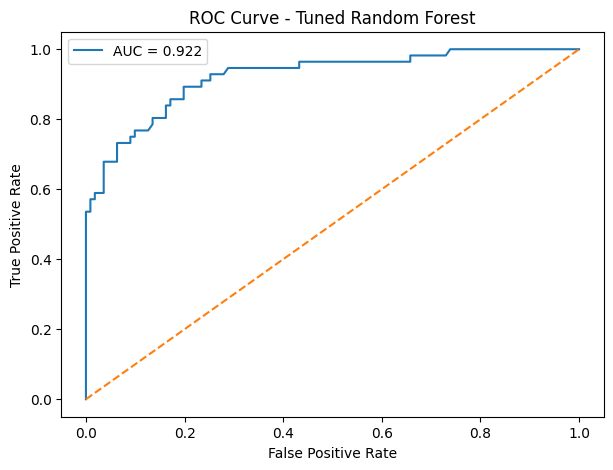

AUC: 0.9223777348777349


In [86]:
y_prob_rf=best_rf.predict_proba(x_test)[:,1]
fpr,tpr, _=roc_curve(y_test,y_prob_rf)
roc_auc_rf=auc(fpr,tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr,label=f'AUC = {roc_auc_rf:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Random Forest')
plt.legend()
plt.show()
print("AUC:", roc_auc_rf)

Best Hyperparameters
The optimal Random Forest configuration obtained through Grid Search was:
- Number of trees (n_estimators): 300
- Maximum tree depth (max_depth): 15
- Minimum samples required to split a node (min_samples_split): 2
- Minimum samples required at a leaf node (min_samples_leaf): 1
The optimized model achieved a cross-validation AUC score of 0.925, indicating strong generalization capability.

Hyperparameter Tuning Results
Hyperparameter optimization slightly improved the performance of the Random Forest classifier.
The optimized model achieved an accuracy of 86.83% and an AUC of 0.922, outperforming the baseline Random Forest model. The improvement confirms that proper parameter selection can enhance predictive performance and model generalization.
Among all evaluated classifiers, the tuned Random Forest achieved the highest AUC score, making it one of the most effective models for this QSAR classification task.

## Hyperparameter Tuning for Gradient Boosting

In [87]:
param_grid={'n_estimators': [100, 200],'learning_rate': [0.01, 0.05, 0.1],'max_depth': [3, 5],'subsample': [0.8, 1.0]}
gb_grid=GridSearchCV(GradientBoostingClassifier(random_state=42),param_grid=param_grid,cv=5,scoring='roc_auc',n_jobs=-1)
gb_grid.fit(x_train, y_train)
print("Best Parameters:")
print(gb_grid.best_params_)
print("\nBest CV AUC:")
print(gb_grid.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Best CV AUC:
0.9236000083887236


In [88]:
best_gb=gb_grid.best_estimator_
y_pred_gb=best_gb.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.874251497005988
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       111
           1       0.87      0.73      0.80        56

    accuracy                           0.87       167
   macro avg       0.87      0.84      0.85       167
weighted avg       0.87      0.87      0.87       167



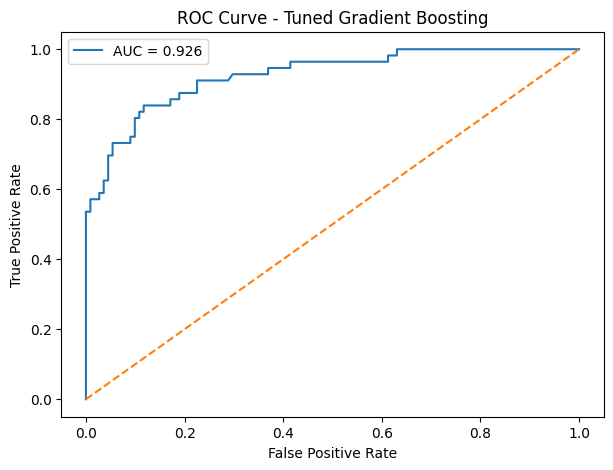

AUC: 0.9259169884169884


In [89]:
y_prob_gb=best_gb.predict_proba(x_test)[:,1]
fpr,tpr,_=roc_curve(y_test, y_prob_gb)
roc_auc_gb=auc(fpr, tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f'AUC = {roc_auc_gb:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Gradient Boosting')
plt.legend()
plt.show()
print("AUC:", roc_auc_gb)

Best Hyperparameters
The optimal Gradient Boosting configuration obtained through Grid Search was:
- Learning Rate: 0.1
- Maximum Tree Depth: 5
- Number of Estimators: 200
- Subsample Ratio: 0.8
The optimized model achieved a cross-validation AUC score of 0.924, indicating strong predictive performance and generalization capability.

Hyperparameter Tuning Results
Hyperparameter optimization improved the performance of the Gradient Boosting classifier.
The tuned model achieved an accuracy of 87.43% and an AUC score of 0.926, outperforming the baseline Gradient Boosting model as well as all other evaluated classifiers.
These results demonstrate the effectiveness of ensemble boosting techniques for QSAR classification and highlight the importance of proper parameter optimization.

## Discussion

In this study, multiple machine learning algorithms were evaluated for the classification of active and inactive compounds using a QSAR dataset. The models included Logistic Regression, Support Vector Machine (SVM), K-Nearest Neighbors (KNN), Decision Tree, Random Forest, Gradient Boosting, AdaBoost, Gaussian Naive Bayes, and Multi-Layer Perceptron (MLP).

The results showed that ensemble-based methods achieved the best overall performance. After hyperparameter optimization, Gradient Boosting obtained the highest classification accuracy (87.43%) and the highest AUC score (0.926), making it the most effective classifier for this dataset. Tuned Random Forest also demonstrated excellent performance with an AUC score of 0.922.

The superior performance of Gradient Boosting and Random Forest can be attributed to their ability to capture complex nonlinear relationships between molecular descriptors and biological activity. Unlike linear models, ensemble methods combine multiple weak learners and are more robust to noise and feature interactions.

Logistic Regression also achieved strong performance, with an AUC score of 0.912. This result suggests that a significant portion of the class separation can be explained by relatively simple decision boundaries. However, ensemble methods were able to capture additional nonlinear patterns and therefore achieved better predictive performance.

The Decision Tree classifier achieved reasonable accuracy but lower AUC compared with ensemble methods. This finding is consistent with the tendency of single decision trees to overfit training data and exhibit limited generalization capability.

Gaussian Naive Bayes produced the lowest classification accuracy among all evaluated models. A likely explanation is the strong independence assumption of the algorithm. Molecular descriptors in QSAR datasets are often correlated, which violates this assumption and reduces predictive performance.

Feature importance analysis revealed that several molecular descriptors consistently contributed to model predictions. In particular, SpMax_B(m) emerged as the most influential feature across multiple tree-based models, including Decision Tree, Random Forest, and AdaBoost. Other important descriptors included SpMax_L, SpPosA_B(p), SM6_B(m), Psi_i_A, F02[C-N], and nN. The consistency of these features across different algorithms increases confidence in their relevance for distinguishing active and inactive compounds.

Overall, the results demonstrate that ensemble learning approaches are highly effective for QSAR classification problems and provide superior predictive performance compared with traditional machine learning methods.


## Conclusion

This study investigated the application of multiple machine learning algorithms for the classification of active and inactive compounds using a QSAR dataset containing molecular descriptors.

A comprehensive comparison was conducted among several classification methods, including Logistic Regression, Support Vector Machine (SVM), K-Nearest Neighbors (KNN), Decision Tree, Random Forest, Gradient Boosting, AdaBoost, Gaussian Naive Bayes, and Multi-Layer Perceptron (MLP). Model performance was evaluated using Accuracy, Precision, Recall, F1-Score, and Area Under the ROC Curve (AUC).

The experimental results demonstrated that ensemble learning methods achieved the best overall performance. After hyperparameter optimization, Gradient Boosting emerged as the most effective classifier, achieving an accuracy of 87.43% and an AUC score of 0.926. Tuned Random Forest also achieved excellent performance, obtaining an AUC score of 0.922.

Feature importance analysis showed that several molecular descriptors played a significant role in predicting compound activity. In particular, SpMax_B(m) consistently appeared as one of the most influential features across multiple tree-based models, highlighting its importance in QSAR modeling.

The findings indicate that ensemble-based approaches are highly suitable for handling complex molecular descriptor datasets and can effectively capture nonlinear relationships between chemical structure and biological activity. Furthermore, the study demonstrates the value of feature importance analysis and hyperparameter optimization in improving predictive performance.

In conclusion, Gradient Boosting and Random Forest were identified as the most reliable models for this QSAR classification task. The results provide useful insights into machine learning applications in cheminformatics and demonstrate the effectiveness of advanced ensemble techniques for molecular activity prediction.


Sama Heidardoost